In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TF version:", tf.__version__)

TF version: 2.20.0


In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [3]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)  # (60000, 28, 28, 1)
x_test  = np.expand_dims(x_test, axis=-1)   # (10000, 28, 28, 1)

print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

x_train: (60000, 28, 28, 1)
x_test : (10000, 28, 28, 1)


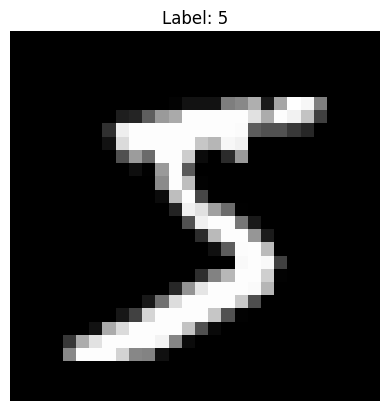

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

In [5]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Block 1
    layers.Conv2D(filters=16, kernel_size=(3,3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Block 2
    layers.Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Classifier head
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()]
)

In [7]:
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=6,
    batch_size=128,
    verbose=1
)

Epoch 1/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.2845 - sparse_categorical_accuracy: 0.9182 - val_loss: 0.0824 - val_sparse_categorical_accuracy: 0.9768
Epoch 2/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0763 - sparse_categorical_accuracy: 0.9774 - val_loss: 0.0564 - val_sparse_categorical_accuracy: 0.9850
Epoch 3/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0540 - sparse_categorical_accuracy: 0.9831 - val_loss: 0.0444 - val_sparse_categorical_accuracy: 0.9882
Epoch 4/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0415 - sparse_categorical_accuracy: 0.9869 - val_loss: 0.0482 - val_sparse_categorical_accuracy: 0.9857
Epoch 5/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0361 - sparse_categorical_accuracy: 0.9888 - val_loss: 0.0391 - val_sparse_categorical_accuracy: 0.9885
Epoch 6/6
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0292 - sparse_categorical_accuracy: 0.9910 - val_loss: 0.0379 - val_sparse_categorical_accuracy: 0.9900


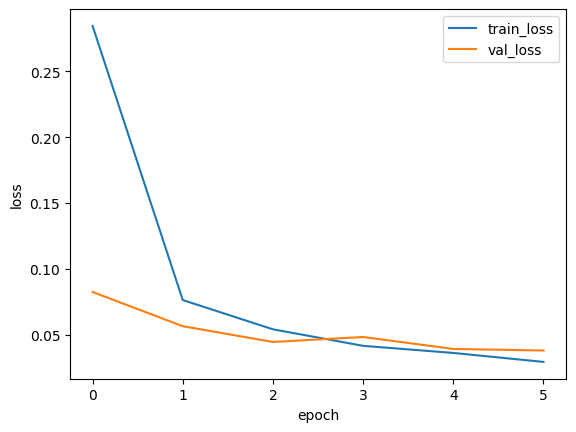

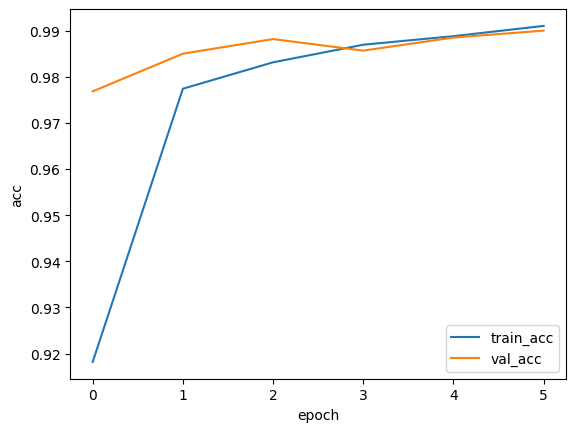

In [8]:
hist = history.history

plt.figure()
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

plt.figure()
plt.plot(hist["sparse_categorical_accuracy"], label="train_acc")
plt.plot(hist["val_sparse_categorical_accuracy"], label="val_acc")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.legend(); plt.show()

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test acc :", test_acc)

Test loss: 0.03332702815532684
Test acc : 0.9890000224113464


In [10]:
from sklearn.metrics import confusion_matrix, classification_report

y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

[[ 976    0    0    1    0    1    0    0    2    0]
 [   0 1127    1    0    1    1    2    1    2    0]
 [   5    1 1018    0    1    0    1    3    3    0]
 [   1    0    1  998    0    5    0    0    2    3]
 [   0    0    0    0  968    0    0    2    1   11]
 [   2    0    0    5    0  881    3    0    0    1]
 [   4    2    0    0    1    4  946    0    1    0]
 [   1    1    4    3    0    0    0 1014    1    4]
 [   2    0    1    0    0    0    1    0  966    4]
 [   1    1    0    1    2    3    0    2    3  996]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99   

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 conv2d Conv2D
1 max_pooling2d MaxPooling2D
2 conv2d_1 Conv2D
3 max_pooling2d_1 MaxPooling2D
4 flatten Flatten
5 dense Dense
6 dense_1 Dense


In [28]:
conv1_layer = model.get_layer(index=0)

feature_extractor = keras.Model(
    inputs=model.inputs,
    outputs=conv1_layer.output
)

sample = x_test[1:2]
features = feature_extractor.predict(sample, verbose=0)

features.shape

(1, 28, 28, 16)

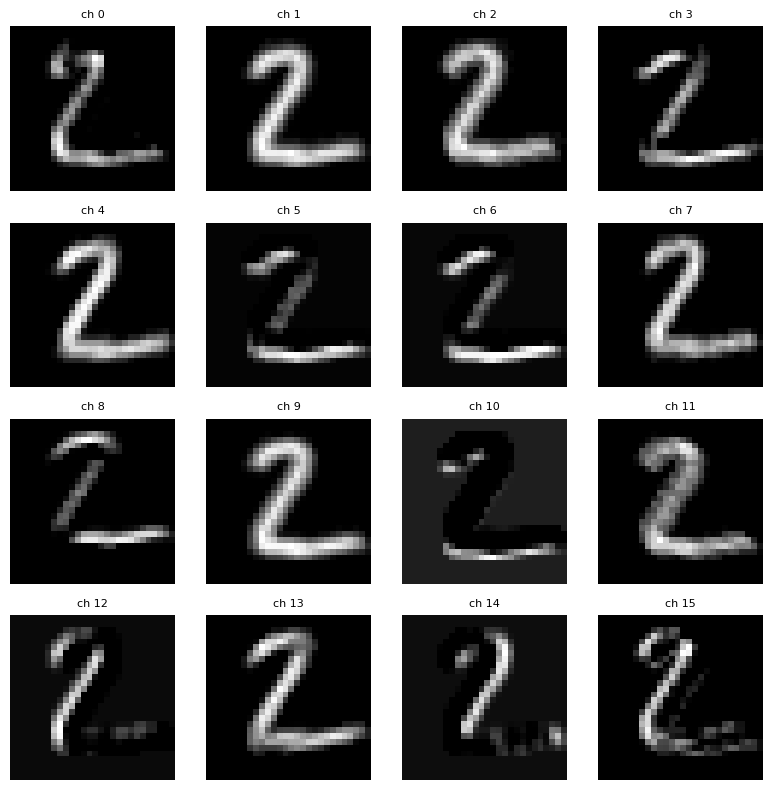

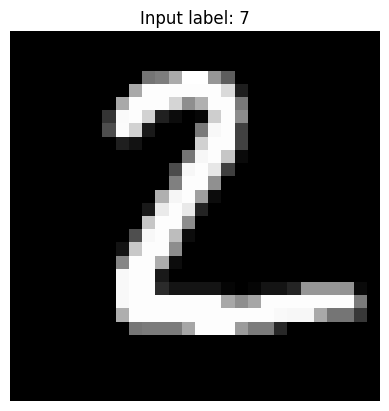

In [29]:
feature_maps = features[0]  # (28, 28, 16)

plt.figure(figsize=(8,8))
for i in range(16):
    ax = plt.subplot(4, 4, i+1)
    plt.imshow(feature_maps[:, :, i], cmap="gray")
    plt.axis("off")
    plt.title(f"ch {i}", fontsize=8)
plt.tight_layout()
plt.show()

plt.figure()
plt.imshow(sample[0].squeeze(), cmap="gray")
plt.title(f"Input label: {y_test[0]}")
plt.axis("off")
plt.show()

In [22]:
conv2_layer = model.get_layer(name="conv2d_1")

In [23]:
feature_extractor_conv2 = keras.Model(
    inputs=model.inputs,
    outputs=conv2_layer.output
)

In [30]:
sample = x_test[1:2]  # giữ batch dim
features_conv2 = feature_extractor_conv2.predict(sample, verbose=0)

features_conv2.shape

(1, 14, 14, 32)

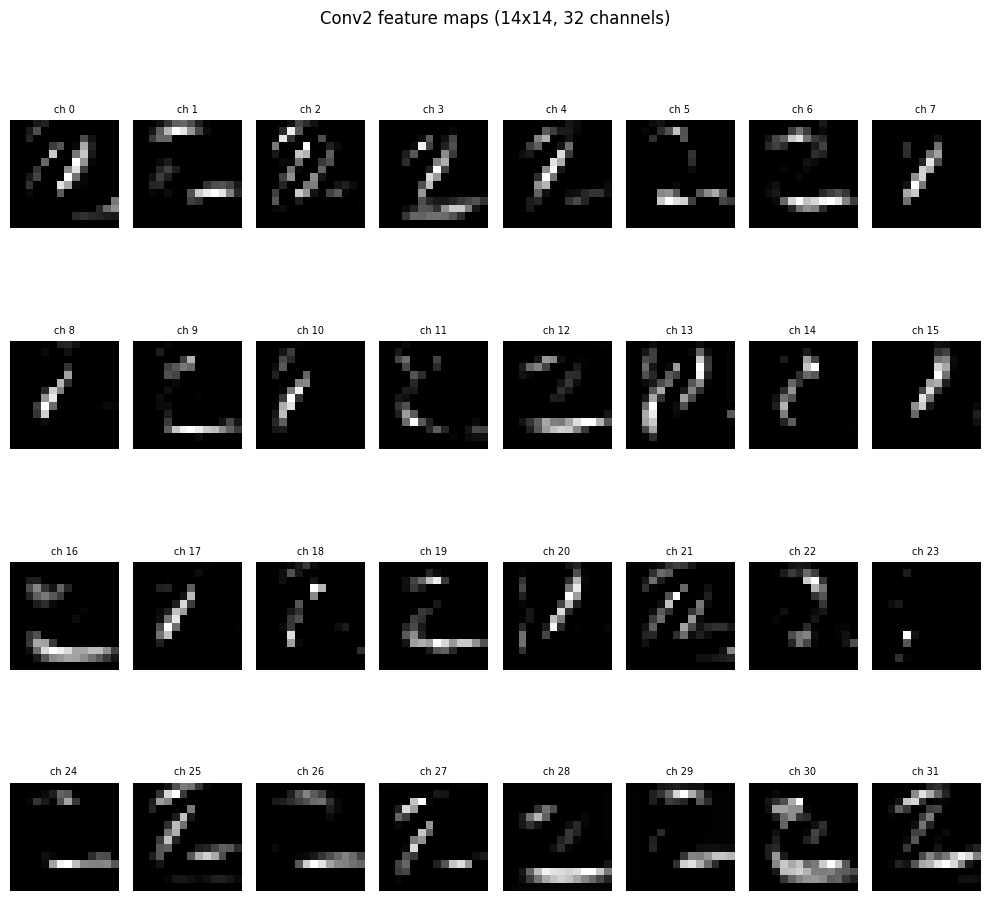

In [31]:
feature_maps = features_conv2[0]  # (14, 14, 32)

plt.figure(figsize=(10,10))
for i in range(32):
    ax = plt.subplot(4, 8, i+1)
    plt.imshow(feature_maps[:, :, i], cmap="gray")
    plt.axis("off")
    plt.title(f"ch {i}", fontsize=7)

plt.suptitle("Conv2 feature maps (14x14, 32 channels)", fontsize=12)
plt.tight_layout()
plt.show()